# 03 - KPI analysis (pandas + SQL)
Fill rate, stockout rate, turnover, days of inventory, ABC, demand variability, lead time, reorder point / safety stock.

Formulas are in `src/kpis.py` (small pure functions) and the same KPIs are written in SQL in `sql/`.

In [1]:
# --- setup: make the project's src/ folder importable and set paths ---
import sys, json
from pathlib import Path
ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
sys.path.insert(0, str(ROOT / "src"))
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
from IPython.display import display, Markdown
import config as cfg
sns.set_theme(style="whitegrid")
pd.set_option("display.width", 160); pd.set_option("display.max_columns", 30)
N = json.loads((cfg.TABLES / "key_numbers.json").read_text())   # every number the scripts computed
%matplotlib inline

In [2]:
import kpis, db
t = kpis.load_clean()
overall = kpis.build_overall_kpis(t)
display(overall.to_frame("value"))

,value
units_demanded,3.265338e+06
revenue,6.151376e+07
lost_revenue,1.075839e+07
fill_rate,8.556995e-01
stockout_rate,1.300061e-01
avg_inventory_value,6.952148e+05
inventory_turnover,2.463442e+01
days_of_inventory,1.446758e+01
n_skus,9.000000e+01
n_days,7.280000e+02


## Cross-check: the same KPIs in SQL (SQLite)
Two independent implementations must agree - a cheap and powerful correctness test.

In [3]:
q = db.parse_named_queries((cfg.SQL_DIR / "01_kpi_queries.sql").read_text())["kpi_overall"]
sql_kpi = db.run_query(q).iloc[0]
cols = ["fill_rate", "stockout_rate", "inventory_turnover", "days_of_inventory", "revenue"]
cmp = pd.DataFrame({"pandas": overall[cols], "sql": sql_kpi[cols]})
cmp["match"] = np.isclose(cmp["pandas"], cmp["sql"]); display(cmp)

,pandas,sql,match
fill_rate,8.556995e-01,8.556995e-01,True
stockout_rate,1.300061e-01,1.300061e-01,True
inventory_turnover,2.463442e+01,2.463442e+01,True
days_of_inventory,1.446758e+01,1.446758e+01,True
revenue,6.151376e+07,6.151376e+07,True


## Service level over time, by category and by warehouse

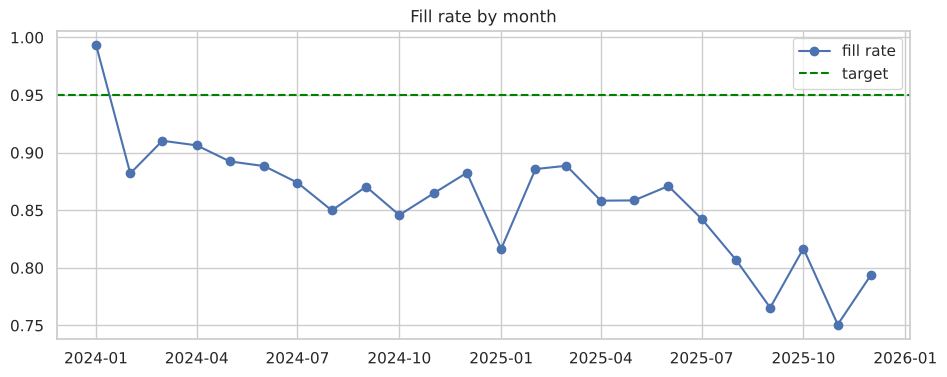

,category,fill_rate,stockout_rate,lost_revenue,inventory_turnover
1,Electronics,0.798647,0.187606,2875187.70,34.360270
5,Textiles,0.812698,0.165628,2346122.20,29.957033
3,Packaging,0.825279,0.183067,1017208.81,30.986207
2,Machinery Parts,0.867696,0.103180,819022.65,29.931942
0,Chemicals,0.879977,0.098549,812142.86,25.712760
4,Raw Materials,0.899272,0.089353,2888708.96,19.747697


,warehouse_code,fill_rate,stockout_rate,lost_revenue
2,WH-EU,0.819871,0.130567,2930236.12
0,WH-APAC,0.849867,0.119363,1629500.20
3,WH-SOUTH,0.856898,0.137166,2153464.54
4,WH-WEST,0.867192,0.135096,2067070.29
1,WH-EAST,0.879782,0.125615,1978122.03


In [4]:
monthly = kpis.build_monthly_kpis(t)
fig, ax = plt.subplots(figsize=(11, 4)); ax.plot(monthly["month"], monthly["fill_rate"], marker="o", label="fill rate")
ax.axhline(cfg.FILL_RATE_TARGET, color="green", ls="--", label="target"); ax.set_title("Fill rate by month"); ax.legend(); plt.show()
cat = kpis.build_cut_kpis(t, "category").sort_values("fill_rate"); display(cat[["category", "fill_rate", "stockout_rate", "lost_revenue", "inventory_turnover"]])
wh = kpis.build_cut_kpis(t, "warehouse_code").sort_values("fill_rate"); display(wh[["warehouse_code", "fill_rate", "stockout_rate", "lost_revenue"]])

## ABC analysis and demand variability
A = SKUs making up the first 80% of revenue, B = next 15%, C = last 5%. CV bands: Low < 0.30, Medium < 0.50, High >= 0.50.

,abc_class,n_skus,revenue,avg_inventory_value,lost_revenue,revenue_share,inventory_share,fill_rate,inventory_turnover
0,A,25,49627956.06,570822.677115,8805246.23,0.806778,0.821074,0.857431,24.371010
1,B,26,8844520.38,90214.534258,1440759.83,0.143781,0.129765,0.852755,25.891841
2,C,39,3041282.21,34177.562720,512387.12,0.049441,0.049161,0.849695,25.714774


cv_band,High,Low,Medium
abc_class,,,
A,0,5,20
B,3,2,21
C,2,4,33


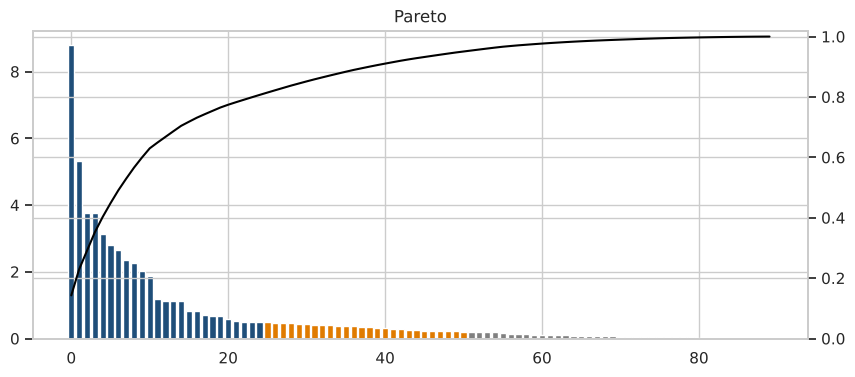

In [5]:
sku = kpis.build_sku_kpis(t)
display(kpis.build_abc_summary(sku, int(overall["n_days"])))
display(pd.crosstab(sku["abc_class"], sku["cv_band"]))
s = sku.sort_values("revenue", ascending=False).reset_index(drop=True)
fig, ax = plt.subplots(figsize=(10, 4)); ax.bar(range(len(s)), s["revenue"] / 1e6, color=s["abc_class"].map({"A": "#1f4e79", "B": "#e07b00", "C": "grey"}))
ax2 = ax.twinx(); ax2.plot(s["revenue"].cumsum() / s["revenue"].sum(), color="black"); ax2.set_ylim(0, 1.02); ax.set_title("Pareto"); plt.show()

## Lead times
Only delivered POs with a valid delivery date are used.

In [6]:
lt_mode = kpis.build_lead_time_by(t, "ship_mode"); display(lt_mode[["ship_mode", "n_pos", "avg_promised_days", "avg_actual_days", "on_time_rate", "lead_time_cv", "freight_pct_of_value"]])
lt_sup = kpis.build_lead_time_by(t, "supplier_code"); display(lt_sup[["supplier_code", "supplier_region", "n_pos", "avg_actual_days", "on_time_rate", "avg_delay_when_late"]].head(8))

,ship_mode,n_pos,avg_promised_days,avg_actual_days,on_time_rate,lead_time_cv,freight_pct_of_value
0,rail,958,16.961378,18.006263,0.490605,0.539424,0.050177
1,ocean,2816,25.341974,25.514560,0.526989,0.359033,0.039671
2,air,2140,6.948598,7.544393,0.546729,0.525564,0.120402
3,road,907,12.652701,13.297685,0.549063,0.698252,0.060536


,supplier_code,supplier_region,n_pos,avg_actual_days,on_time_rate,avg_delay_when_late
0,SUP-012,East Asia,452,17.504425,0.396018,4.135531
1,SUP-002,East Asia,229,19.737991,0.427948,6.274809
2,SUP-014,South Asia,162,16.604938,0.450617,4.808989
3,SUP-023,South Asia,121,20.363636,0.462810,4.569231
4,SUP-013,Latin America,373,15.831099,0.469169,4.959596
5,SUP-008,South Asia,333,17.345345,0.504505,5.606061
6,SUP-009,Latin America,338,22.831361,0.511834,7.987879
7,SUP-020,Latin America,152,12.046053,0.513158,5.135135


## Reorder point and safety stock: current policy vs recommended
`safety stock = z * sqrt((LT + R) * sigma_d^2 + mean_d^2 * sigma_LT^2)`, `ROP = mean_d * LT + safety stock`, using the last 13 weeks of demand and the supplier's measured lead time.

In [7]:
pol = kpis.build_policy_check(t)
display(pol[["sku", "warehouse_code", "reorder_point_units", "rec_reorder_point", "rop_gap_pct", "recent_stockout_rate", "recent_lost_revenue"]].sort_values("recent_lost_revenue", ascending=False).head(8))
under = pol[pol["under_protected"] == 1]; ok = pol[pol["under_protected"] == 0]
print(f"under-protected: {len(under)} of {len(pol)} | stockout rate {under['recent_stockout_rate'].mean():.1%} vs {ok['recent_stockout_rate'].mean():.1%}")

,sku,warehouse_code,reorder_point_units,rec_reorder_point,rop_gap_pct,recent_stockout_rate,recent_lost_revenue
71,SKU-00037,WH-EU,3425,7067.937468,0.515417,0.340659,226864.30
96,SKU-00049,WH-EU,1232,2461.163318,0.499424,0.494505,165938.65
102,SKU-00053,WH-EU,865,2531.625022,0.658322,0.516484,132909.63
104,SKU-00053,WH-APAC,1184,3215.113692,0.631739,0.417582,132119.96
47,SKU-00024,WH-EAST,2166,4104.693114,0.472311,0.252747,120114.48
103,SKU-00053,WH-WEST,1283,3434.950355,0.626487,0.318681,109682.44
97,SKU-00049,WH-SOUTH,969,2008.869644,0.517639,0.417582,95956.62
48,SKU-00024,WH-APAC,2643,5199.739069,0.491705,0.131868,65499.32


under-protected: 164 of 180 | stockout rate 19.7% vs 2.1%


In [8]:
display(Markdown(f"""### So what
* Fill rate is **{N['kpi_fill_rate']:.1%}** (target {N['kpi_target']:.0%}); lost revenue **${N['kpi_lost_revenue']/1e6:,.2f}M**. It {'fell' if N['kpi_fill_last_3m'] < N['kpi_fill_first_3m'] else 'rose'} from {N['kpi_fill_first_3m']:.1%} to {N['kpi_fill_last_3m']:.1%}.
* **ABC:** A items are {N['abc_a_sku_share']:.0%} of SKUs, {N['abc_a_revenue_share']:.0%} of revenue and {N['abc_a_lost_revenue_share']:.0%} of lost revenue, yet fill rates are A {N['abc_a_fill']:.1%} / B {N['abc_b_fill']:.1%} / C {N['abc_c_fill']:.1%}. **Action:** service targets by class.
* **Policy:** {N['pol_under_n']} of {N['pol_n_sku_wh']} SKU-warehouses are under-protected; they stock out on {N['pol_stockout_under']:.1%} of days vs {N['pol_stockout_ok']:.1%}. **Action:** quarterly refresh of ROP/safety stock, starting with the highest lost-revenue SKU-warehouses.
* **Suppliers:** {N['lt_on_time_rate']:.1%} of POs are on time; air freight costs {N['lt_air_freight_pct']:.1%} of value vs {N['lt_nonair_freight_pct']:.1%} otherwise. **Action:** supplier scorecard, fewer emergency shipments."""))

### So what
* Fill rate is **85.6%** (target 95%); lost revenue **$10.76M**. It fell from 92.9% to 78.7%.
* **ABC:** A items are 28% of SKUs, 81% of revenue and 82% of lost revenue, yet fill rates are A 85.7% / B 85.3% / C 85.0%. **Action:** service targets by class.
* **Policy:** 164 of 180 SKU-warehouses are under-protected; they stock out on 19.7% of days vs 2.1%. **Action:** quarterly refresh of ROP/safety stock, starting with the highest lost-revenue SKU-warehouses.
* **Suppliers:** 53.1% of POs are on time; air freight costs 12.0% of value vs 4.5% otherwise. **Action:** supplier scorecard, fewer emergency shipments.